In [1]:
import h5py
file = 'geo/geo_ifgramStack.h5'
with h5py.File(file, 'r') as f:
    for key in f.keys():
        print("  ", key)

   bperp
   coherence
   connectComponent
   date
   dropIfgram
   unwrapPhase


In [2]:
#! temporal_average.py inputs/ifgramStack.h5 -d coherence -o avgSpatialCoh.h5

In [3]:
#!info.py avgSpatialCoh.h5

In [4]:
#!geocode.py avgSpatialCoh.h5 -l inputs/geometryRadar.h5 -o geo/geo_avgSpatialCoh.h5
#!geocode.py inputs/ifgramStack.h5 -l inputs/geometryRadar.h5 -d connectComponent -o geo/geo_ifgramStack.h5  -i nearest
#!geocode.py inputs/ifgramStack.h5 -l inputs/geometryRadar.h5 -d coherence -o geo/geo_coherence.h5 --update

In [5]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.ticker import AutoMinorLocator
from mintpy.utils import readfile
from skimage import measure, morphology
from scipy.ndimage import label, uniform_filter, generate_binary_structure
from datetime import datetime
import pandas as pd
import datetime
from scipy.interpolate import interp1d
from scipy.stats import pearsonr
import contextily as cx
from pyproj import Transformer

In [6]:
COH_THRESHOLD = 0.7
PERC_THD=0.9
DAM_LAT, DAM_LON = -33.5075, 149.0100
PIT_LAT, PIT_LON = -33.4650, 149.0100
CONN_THRESH = 0.5
path_coh_thd = 0.5
MIN_AREA_PIXELS = 10
QUALITY_THD = 30  #At least 30 pixels must be connected to failed zone
DENSITY_REQ = 0.8  # 80% of neighbors must be good
WIN_SIZE    = 5    # 5x5 Window
dam_l=20
dam_b=40
pit_r=20

GEO_SCOH_FILE = 'geo/geo_avgSpatialCoh.h5'  # Background Map
GEO_CONN_FILE = 'geo/geo_ifgramStack.h5'   # Connectivity Data
GEO_STACK_FILE = 'geo/geo_coherence.h5'    #Coherence Stackc file
h5_path  = 'geo/geo_timeseries_ERA5_demErr.h5'
bg_img = mpimg.imread('Cadia_GIS2.tif')

s_data, attr = readfile.read(GEO_SCOH_FILE, datasetName='coherence') #Coherence Stack
coh_stack, attr = readfile.read(GEO_STACK_FILE, datasetName='coherence')
conn_stack, _ = readfile.read(GEO_CONN_FILE, datasetName='connectComponent') # Connectivity Stack


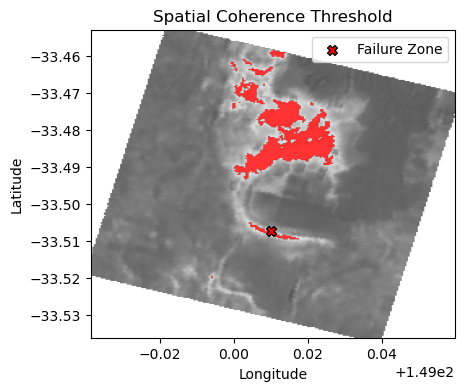

In [7]:
#Coherence Threshold Application
rows, cols = s_data.shape
x0, dx = float(attr['X_FIRST']), float(attr['X_STEP'])
y0, dy = float(attr['Y_FIRST']), float(attr['Y_STEP'])
extent = [x0, x0 + cols*dx, y0 + rows*dy, y0]
only_coh_mask = s_data > COH_THRESHOLD #Coherence Mask

#  PLOTTING 
plt.figure(figsize=(5, 4))
plt.imshow(s_data, cmap='gray', vmin=0, vmax=.8, extent=extent)
overlay = np.zeros((rows, cols, 4))
overlay[only_coh_mask, :] = [1, 0, 0, 0.8]  # Red with 80% transparency
plt.imshow(overlay, extent=extent)

plt.scatter(DAM_LON, DAM_LAT, c='red', marker='X', s=50, edgecolors='black', label='Failure Zone')
plt.title(f"Spatial Coherence Threshold")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()


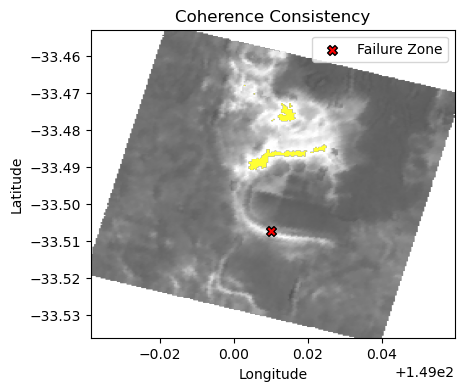

In [8]:
#Coherence Percentage Threshold APplication
rows, cols = coh_stack.shape[1], coh_stack.shape[2]
high_coh_stack = coh_stack > COH_THRESHOLD 
high_coh_counts = np.sum(high_coh_stack, axis=0)

coh_consistency = high_coh_counts / coh_stack.shape[0]
coh_mask = coh_consistency > PERC_THD

plt.figure(figsize=(5, 4))
plt.imshow(s_data, cmap='gray', vmin=0, vmax=.8, extent=extent)
overlay = np.zeros((rows, cols, 4))
overlay[coh_mask, :] = [1, 1, 0, 0.8]  # Yellow with 80% transparency
plt.imshow(overlay, extent=extent)

plt.scatter(DAM_LON, DAM_LAT, c='red', marker='X', s=50, edgecolors='black', label='Failure Zone')
plt.title(f"Coherence Consistency")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()


Target Pixel: (165, 110)
Connected Stable Candidates: 322


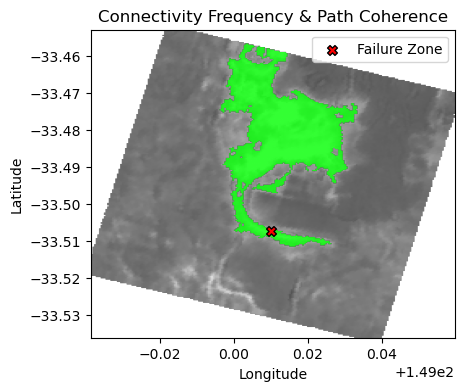

In [9]:
#Connectivity Coherence Threhold & Minimum Number of Connected Pixel Required

dam_y = int((DAM_LAT - y0) / dy)
dam_x = int((DAM_LON - x0) / dx)

# Compare every pixel to the Dam's pixel over time
dam_series = conn_stack[:, dam_y, dam_x]
conn_freq = np.mean((conn_stack == dam_series[:, None, None]) & (conn_stack != 0), axis=0)

island = conn_freq > CONN_THRESH # Connectivity Mask
valid_connection_count = np.sum(coh_mask & island)

print(f"Target Pixel: ({dam_y}, {dam_x})")
print(f"Connected Stable Candidates: {valid_connection_count}")

# Generate the spatial bridge mask and the initial intersection
bridge_mask = (s_data > path_coh_thd)
con_island = (island & bridge_mask)
    
# Group the valid spatial pixels into connected clusters
labels = measure.label(bridge_mask, connectivity=2)
target_label = labels[dam_y, dam_x]
    
# Prevent selecting the entire background if the target pixel is decorrelated
if target_label == 0:
    print("WARNING: Target pixel coherence is below path_coh_thd. It does not belong to a valid path.")
    path_island_mask = np.zeros_like(bridge_mask, dtype=bool)
else:
    path_island_mask = (labels == target_label)
    
con_island_2 = (con_island & path_island_mask)
    
# PLOTTING 
plt.figure(figsize=(5, 4))
plt.imshow(s_data, cmap='gray', vmin=0, vmax=.8, extent=extent)
overlay = np.zeros((rows, cols, 4))
overlay[con_island_2, :] = [0, 1, 0, 0.8]  # Green with 80% alpha
plt.imshow(overlay, extent=extent) 
plt.scatter(DAM_LON, DAM_LAT, c='red', marker='X', s=50, edgecolors='black', label='Failure Zone')
plt.title(f"Connectivity Frequency & Path Coherence")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()

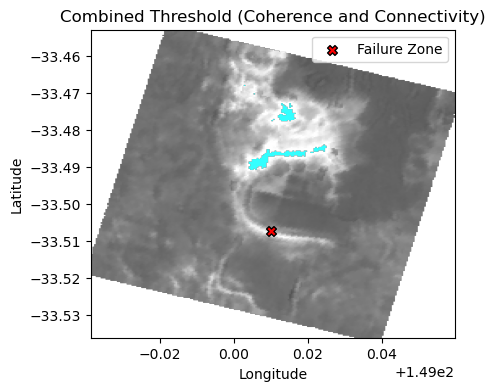

In [10]:
#Combination of Connectivity and COherence

com_mask = (coh_mask & con_island_2)

# PLOTTING 
plt.figure(figsize=(6, 4))
plt.imshow(s_data, cmap='gray', vmin=0, vmax=.8, extent=extent)
overlay = np.zeros((rows, cols, 4))
overlay[com_mask, :] = [0, 1, 1, 0.8]  
plt.imshow(overlay, extent=extent)

plt.scatter(DAM_LON, DAM_LAT, c='red', marker='X', s=50, edgecolors='black', label='Failure Zone')
plt.title(f"Combined Threshold (Coherence and Connectivity)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()

Pixels before area filtering: 322
Pixels after area filtering: 313


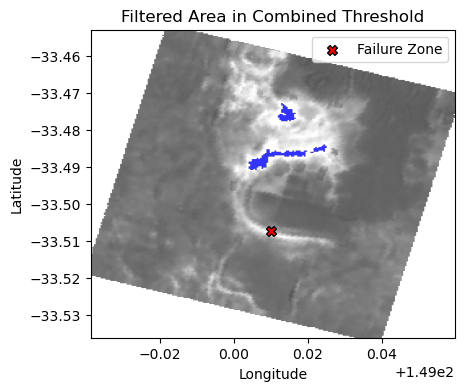

In [11]:
#Filtering Out Area with Isolated Pixel ( Small Size)

labeled_mask = measure.label(com_mask > 0, connectivity=2)
cleaned_mask = morphology.remove_small_objects(labeled_mask, min_size=MIN_AREA_PIXELS)
filt_mask = (cleaned_mask > 0).astype(np.uint8)

print(f"Pixels before area filtering: {np.sum(com_mask)}")
print(f"Pixels after area filtering: {np.sum(filt_mask)}")

plt.figure(figsize=(6, 4))
plt.imshow(s_data, cmap='gray', vmin=0, vmax=.8, extent=extent)
overlay = np.zeros((rows, cols, 4))
overlay[filt_mask == 1, :] = [0, 0, 1, 0.8]  # Bright Red, High Visibility
plt.imshow(overlay, extent=extent)

plt.scatter(DAM_LON, DAM_LAT, c='red', marker='X', s=50, edgecolors='black', label='Failure Zone')
plt.title(f"Filtered Area in Combined Threshold")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()


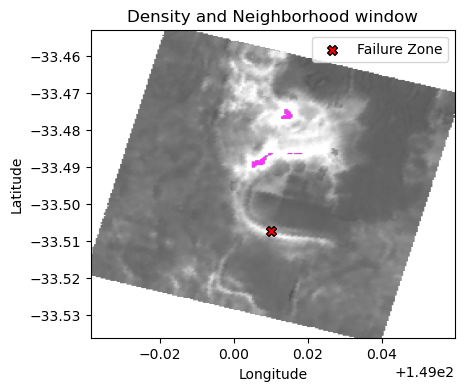

In [12]:
#Filtering Out Zone with neighbor Density and Window Size
com_map = filt_mask.astype(bool)
density_score = uniform_filter(com_map.astype(float), size=WIN_SIZE)
density_mask = com_map & (density_score >= DENSITY_REQ)
final_mask = density_mask.astype(np.int8)

plt.figure(figsize=(6, 4))
plt.imshow(s_data, cmap='gray', vmin=0, vmax=.8, extent=extent)
final_img = np.zeros((rows, cols, 4))
final_img[final_mask == 1, :] = [1, 0, 1, 0.8] 
plt.imshow(final_img, extent=extent)
plt.scatter(DAM_LON, DAM_LAT, c='red', marker='X', s=50, edgecolors='black', label='Failure Zone')
plt.title(f"Density and Neighborhood window")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.show()


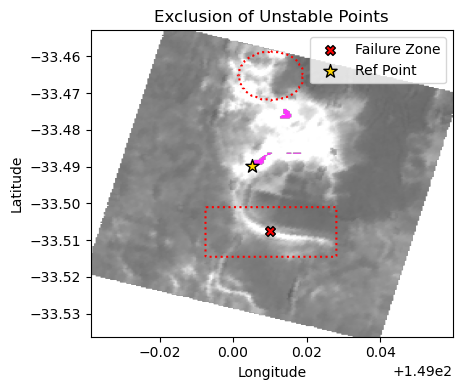

OPTIMUM REF POINT (Rectangular)
Geo: -33.48982, 149.00524
Pixel: X = 100, Y = 112


In [13]:
#Filtering Out Dam and Pit Area (The Area where we cannot have reference Point)
lat0, lon0 = float(attr['Y_FIRST']), float(attr['X_FIRST'])
lat_step, lon_step = float(attr['Y_STEP']), float(attr['X_STEP'])

dam_y = int(round((DAM_LAT - lat0) / lat_step))
dam_x = int(round((DAM_LON - lon0) / lon_step))
pit_y = int(round((PIT_LAT - lat0) / lat_step))
pit_x = int(round((PIT_LON - lon0) / lon_step))

y, x = np.ogrid[:rows, :cols]
excl = ((np.abs(x - dam_x) <= dam_b) & (np.abs(y - dam_y) <= dam_l)) | (np.hypot(x - pit_x, y - pit_y) <= pit_r)
cand = final_mask.astype(bool) & ~excl
final_mask_filt = final_mask & (~excl)
cy, cx = np.where(cand)
if len(cy) > 0:
    idx = np.argmin(np.hypot(cx - dam_x, cy - dam_y))
    py, px = cy[idx], cx[idx]
    lat_r, lon_r = lat0 + py * lat_step, lon0 + px * lon_step

plt.figure(figsize=(6, 4))
plt.imshow(s_data, cmap='gray', vmin=0, vmax=.7, extent=extent)
overlay = np.zeros((rows, cols, 4))
#overlay[excl] = [1, 0, 0, 0.8] 
overlay[cand] = [1, 0, 1, 0.8]  
plt.imshow(overlay, extent=extent)
plt.contour(excl, levels=[0.5], colors='red', linestyles='dotted', linewidths=1.5, extent=extent, origin='upper')

plt.scatter(DAM_LON, DAM_LAT, c='red', marker='X', s=50, edgecolors='black', label='Failure Zone')
plt.scatter(lon_r, lat_r, c='gold', marker='*', s=100, edgecolors='k', label='Ref Point')
plt.title(f"Exclusion of Unstable Points")
plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.legend(); plt.tight_layout(); plt.show()

print(f"OPTIMUM REF POINT (Rectangular)\nGeo: {lat_r:.5f}, {lon_r:.5f}\nPixel: X = {px}, Y = {py}")

In [14]:
#AFTER THIS RUN MINTPY AND GENERATE TEMPORAL COHERENCE AND STANDARD DEVIATION
#In this research we have not incorporated temporal coherence and velocity standard deviation as they did not have significant impact

In [16]:
TCOH_FILE = './geo/geo_temporalCoherence.h5'
SD_FILE = 'geo/geo_velocity.h5'
TCOH_THRESH = 0.0   # Stability Threshold
SD_THRESH = 0.1 #Standard Deviation Threshold

t_data, atr = readfile.read(TCOH_FILE, datasetName='temporalCoherence')
sd_data, _ = readfile.read(SD_FILE, datasetName='velocityStd')

rows, cols = t_data.shape
lat0, lon0 = float(atr['Y_FIRST']), float(atr['X_FIRST'])
lat_step, lon_step = float(atr['Y_STEP']), float(atr['X_STEP'])
extent = [lon0, lon0 + cols*lon_step, lat0 + rows*lat_step, lat0]

def get_yx(lat, lon):
    return int((lat - lat0) / lat_step + 0.5), int((lon - lon0) / lon_step + 0.5)

dam_y, dam_x = get_yx(DAM_LAT, DAM_LON)
pit_y, pit_x = get_yx(PIT_LAT, PIT_LON)

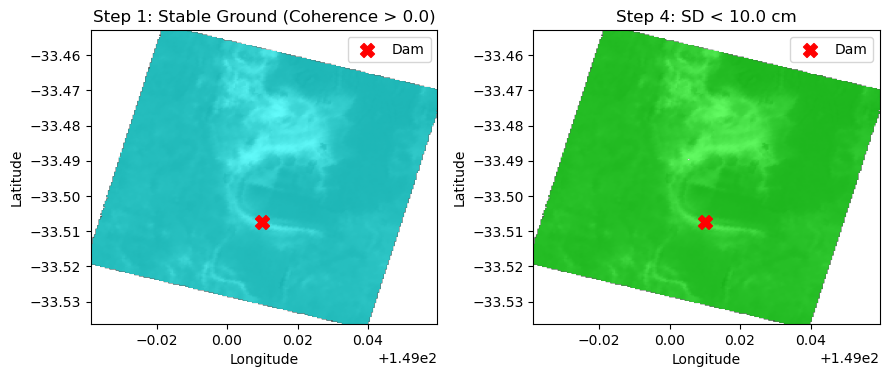

In [17]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 5))

# Masks & Overlays
tcoherence = t_data > TCOH_THRESH
sd_map = (sd_data > 0) & (sd_data < SD_THRESH)

o1, o2 = np.zeros((rows, cols, 4)), np.zeros((rows, cols, 4))
o1[tcoherence] = [0, 1, 1, 0.6]  # Cyan
o2[sd_map] = [0, 1, 0, 0.6]      # Green 

# Plot Step 1 (Left)
ax1.imshow(s_data, cmap='gray', vmin=0, vmax=1, extent=extent)
ax1.imshow(o1, extent=extent)
ax1.set_title(f"Step 1: Stable Ground (Coherence > {TCOH_THRESH})")

# Plot Step 4 (Right)
ax2.imshow(s_data, cmap='gray', vmin=0, vmax=1, extent=extent)
ax2.imshow(o2, extent=extent)
ax2.set_title(f"Step 4: SD < {SD_THRESH*100} cm")

# Common Elements (Legend & Axis Labels)
for ax in (ax1, ax2):
    ax.scatter(DAM_LON, DAM_LAT, c='red', marker='X', s=100, label='Dam')
    ax.set_xlabel("Longitude")
    ax.set_ylabel("Latitude")
    ax.legend()

plt.tight_layout()
plt.show()

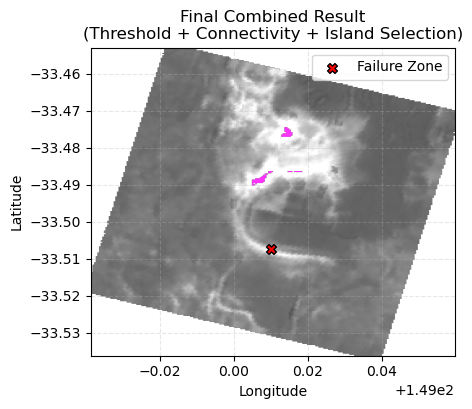

Pixels in Initial Mask: 94
Pixels in FINAL intersection: 93


In [18]:
#Combination of Temporal COherence and Standard Deviation with previous Result
final_mask_cohsd = (final_mask_filt & tcoherence & sd_map ).astype(np.int8)

plt.figure(figsize=(6, 4))
plt.imshow(s_data, cmap='gray', vmin=0, vmax=.8, extent=extent)
final_overlay = np.zeros((rows, cols, 4))
final_overlay[final_mask_cohsd  == 1, :] = [1, 0, 1, 0.8] 
plt.imshow(final_overlay, extent=extent)

# Reference Markers
plt.scatter(DAM_LON, DAM_LAT, c='red', marker='X', s=50, edgecolors='black', label='Failure Zone')
plt.title(f"Final Combined Result\n(Threshold + Connectivity + Island Selection)")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.show()

print(f"Pixels in Initial Mask: {np.sum(final_mask)}")
print(f"Pixels in FINAL intersection: {np.sum(final_mask_cohsd)}")

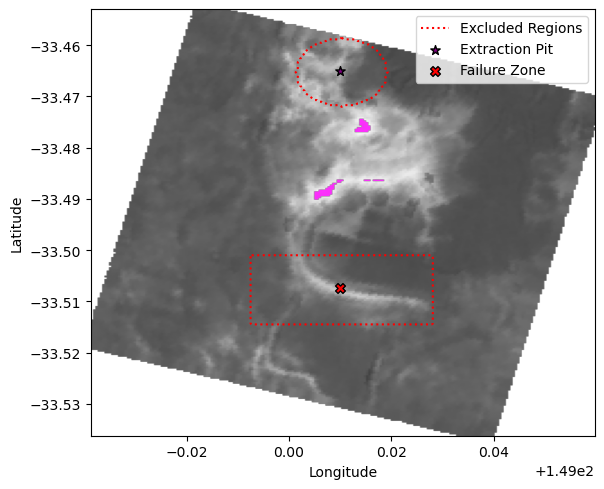

In [19]:
final_revised_mask = final_mask_cohsd & (~excl)
#Plot Exclusion
plt.figure(figsize=(8, 5))
plt.imshow(s_data, cmap='gray', vmin=0, vmax=1, extent=extent)

# Combine masks into a single overlay array
overlay = np.zeros((rows, cols, 4))
overlay[cand] = [1, 0, 1, 0.8]  
plt.imshow(overlay, extent=extent)
plt.contour(excl, levels=[0.5], colors='red', linestyles='dotted', linewidths=1.5, extent=extent, origin='upper')
plt.plot([], [], color='red', linestyle='dotted', linewidth=1.5, label='Excluded Regions')
plt.scatter(PIT_LON, PIT_LAT, c='purple', marker='*', s=50, edgecolors='black', label='Extraction Pit')
plt.scatter(DAM_LON, DAM_LAT, c='red', marker='X', s=50, edgecolors='black', label='Failure Zone')
plt.xlabel("Longitude"); plt.ylabel("Latitude"); plt.tight_layout();  plt.legend(); plt.show();


Detected 3 valid reference points after filtering.
Ref 1 | Rank 1 | Lat: -33.48982, Lon: 149.00524 | Dist: 55.11px
Ref 2 | Rank 2 | Lat: -33.48620, Lon: 149.01447 | Dist: 65.76px
Ref 3 | Rank 3 | Lat: -33.47665, Lon: 149.01271 | Dist: 94.19px


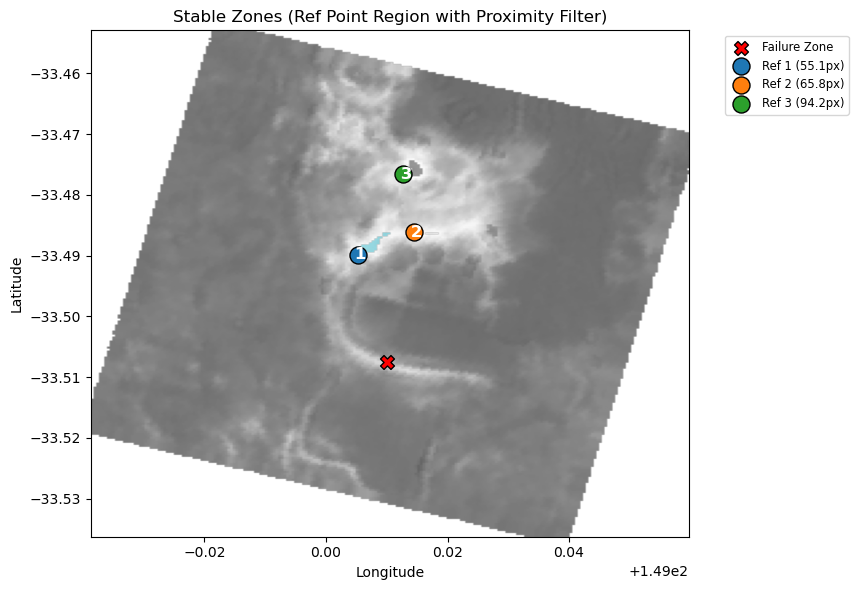

In [20]:
# IDENTIFY & RANK CLOSEST POINTS
labeled, num_features = label(final_revised_mask, structure=np.ones((3,3)))

mask_rows, mask_cols = final_revised_mask.shape 
y_g, x_g = np.indices((mask_rows, mask_cols))
dist_map = np.hypot(x_g - dam_x, y_g - dam_y)

pts = []
for i in range(1, num_features + 1):
    py, px = np.where(labeled == i)
    y, x = py[np.argmin(dist_map[py, px])], px[np.argmin(dist_map[py, px])]
    # Store pixel coordinates (y, x) to calculate distances between islands
    pts.append({'Dist': dist_map[y, x], 'Lat': lat0 + y*lat_step, 'Lon': lon0 + x*lon_step, 'y': y, 'x': x})

all_sorted = sorted(pts, key=lambda d: d['Dist']) # Sort all potential points by distance to dam first

# Filter islands that are too close to each other 
ranked = []
for p in all_sorted:
    is_too_close = False
    for r_pt in ranked:
        inter_island_dist = np.hypot(p['x'] - r_pt['x'], p['y'] - r_pt['y'])
        if inter_island_dist < 5:
            is_too_close = True
            break    
    if not is_too_close:
        ranked.append(p)

print(f"Detected {len(ranked)} valid reference points after filtering.")
for r, p in enumerate(ranked, 1):
    print(f"Ref {r} | Rank {r} | Lat: {p['Lat']:.5f}, Lon: {p['Lon']:.5f} | Dist: {p['Dist']:.2f}px")

# VISUALIZATION
plt.figure(figsize=(10, 6))
plt.imshow(s_data, cmap='gray', extent=extent, alpha=0.6)
plt.imshow(np.where(final_revised_mask > 0, labeled, np.nan), cmap='nipy_spectral', extent=extent, alpha=0.4)
plt.scatter(DAM_LON, DAM_LAT, c='red', marker='X', s=100, edgecolors='black', label='Failure Zone', zorder=5)
for r, p in enumerate(ranked, 1):
    plt.scatter(p['Lon'], p['Lat'], ec='k', s=150, label=f"Ref {r} ({p['Dist']:.1f}px)")
    plt.text(p['Lon'], p['Lat'], f" {r}", color='w', weight='bold', fontsize=12, ha='center', va='center')
plt.title("Stable Zones (Ref Point Region with Proximity Filter)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.tight_layout()
plt.show()

In [21]:
#Select Optimim Reference point 

In [22]:
import h5py

def coord_to_index(h5_file, lats, lons):
    with h5py.File(h5_file, 'r') as f:
        attrs = f.attrs
        x_step, y_step = float(attrs['X_STEP']), float(attrs['Y_STEP'])
        x_first, y_first = float(attrs['X_FIRST']), float(attrs['Y_FIRST'])
        col_indices = [int(round((lon - x_first) / x_step)) for lon in lons]
        row_indices = [int(round((lat - y_first) / y_step)) for lat in lats]
        return row_indices, col_indices

# Automatically extract reference points from the 'ranked' list
target_lats = [p['Lat'] for p in ranked]
target_lons = [p['Lon'] for p in ranked]

# Append the constant Failure Zone coordinates to the end
FAILURE_LAT = -33.5075
FAILURE_LON = 149.009
target_lats.append(FAILURE_LAT)
target_lons.append(FAILURE_LON)

# Set indices 
FAILURE_IDX = len(target_lats) - 1       # Always the last item in the list
REF_INDICES = list(range(len(ranked)))  

# Map Coordinates to Indices
rows, cols = coord_to_index(h5_path, target_lats, target_lons)

print(f"Target Lats: {target_lats}")
print(f"Target Lons: {target_lons}")
print(f"Mapped Rows: {rows}, Mapped Cols: {cols}")

Target Lats: [-33.48981805797015, -33.486196233342156, -33.47664778659563, -33.5075]
Target Lons: [149.00524302936896, 149.0144683476454, 149.01271114416417, 149.009]
Mapped Rows: [112, 101, 72, 166], Mapped Cols: [100, 121, 117, 109]


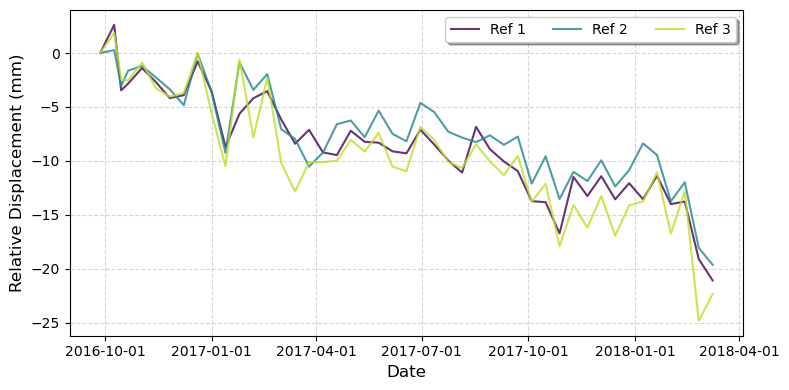

In [23]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

def get_dates(h5_file):   
    with h5py.File(h5_file, 'r') as f:    
        date_list_str = f['date'][:]           
        dates = [datetime.datetime.strptime(d.decode('utf-8'), '%Y%m%d') for d in date_list_str]
        return dates

def extract_timeseries(h5_file, rows, cols):    
    with h5py.File(h5_file, 'r') as f:       
        ds_name = 'timeseries'
        if ds_name not in f.keys():            
            ds_name = list(f.keys())[0]          
        data = f[ds_name] 
        timeseries_list = []
        for r, c in zip(rows, cols):            
            ts = data[:, r, c] 
            timeseries_list.append(ts)
            
        return timeseries_list

dates = get_dates(h5_path)
ts_data = extract_timeseries(h5_path, rows, cols)
failure_ts = ts_data[FAILURE_IDX]
ref_ts_list = [ts_data[i] for i in REF_INDICES]

fig, ax = plt.subplots(figsize=(8, 4))
num_refs = len(REF_INDICES)
colors = plt.cm.viridis(np.linspace(0, 0.9, num_refs)) 

for i, ref_ts in enumerate(ref_ts_list):    
    relative_disp_mm = (failure_ts - ref_ts) * 1000  # Calculate relative displacement and convert to mm
    label_text = f"Ref {i+1}"
    ax.plot(dates, relative_disp_mm, label=label_text, color=colors[i], linewidth=1.5, alpha=0.8)

ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
ax.set_ylabel("Relative Displacement (mm)", fontsize=12)
ax.set_xlabel("Date", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.5)

ax.legend(loc='best', frameon=True, shadow=True, ncol=3)
plt.tight_layout()

plt.show()

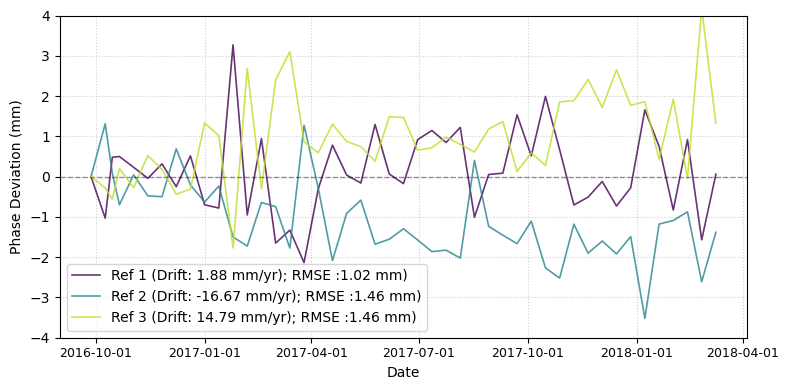

Stability Rankings
  Ref      Drift      Std     RMSE
Ref 1   1.875251 1.016866 1.023960
Ref 3  14.794960 1.087547 1.455131
Ref 2 -16.670210 0.970752 1.457438


In [24]:
def get_data(h5_file):
    with h5py.File(h5_file, 'r') as f:
        d_key = 'timeseries' if 'timeseries' in f else list(f.keys())[0]
        return [datetime.datetime.strptime(d.decode('utf-8'), '%Y%m%d') for d in f['date'][:]], f[d_key][:]
        
REFS = {0: ('P0', 'green'), 1: ('P1', 'blue'), 2: ('P2', 'orange')} 
rows, cols = coord_to_index(h5_path, target_lats, target_lons)
dates, full_data = get_data(h5_path)
ts = {i: full_data[:, rows[i], cols[i]] * 1000 for i in REFS}
nums = np.arange(len(ts[0]))

rows, cols = coord_to_index(h5_path, target_lats, target_lons)
dates, full_data = get_data(h5_path)
mean_ts = np.mean(list(ts.values()), axis=0)
plt.figure(figsize=(8, 4)) 
metrics = []

for i, (idx, col) in enumerate(zip(REF_INDICES, colors)):
    dev = ts[idx] - mean_ts
    drift = np.polyfit(nums, dev, 1)[0] * 365.25
    lbl = f"Ref {i+1}"
    metrics.append({'Ref': lbl, 'Drift': drift, 'Abs': abs(drift), 'Std': np.std(dev), 'RMSE': np.sqrt(np.mean(dev**2))})
    plt.plot(dates, dev, label=f"{lbl} (Drift: {drift:.2f} mm/yr); RMSE :{np.sqrt(np.mean(dev**2)):.2f} mm)", color=col, lw=1.2, alpha=0.8)

ax = plt.gca()
ax.set_ylim(-4, 4)
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.xticks(rotation=0, ha='center', fontsize=9) 
plt.axhline(0, color='k', ls='--', alpha=0.4, lw=1)
plt.ylabel("Phase Deviation (mm)")
plt.xlabel("Date")
plt.legend(loc='lower left') # Compact legend
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

df = pd.DataFrame(metrics).sort_values('Abs')
print(f"Stability Rankings\n{df[['Ref', 'Drift', 'Std', 'RMSE']].to_string(index=False)}")


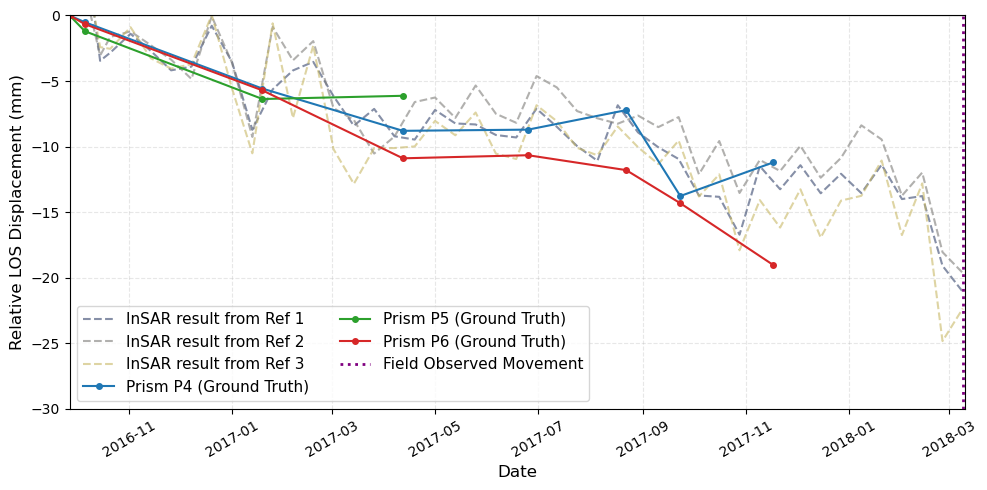

In [25]:
file_name = 'ANalysis FILES/Prism_Cadia.xlsx'
df = pd.read_excel(file_name, sheet_name='m_raw')
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)

# Incidence angle and heading
theta = np.radians(43.088783)  
alpha = np.radians(-13.267909) 

def calculate_los(row, prism_prefix):
    d_ver = row[f'{prism_prefix} Ver']   # Up
    d_perp = row[f'{prism_prefix} Perp'] # North/South
    d_par = row[f'{prism_prefix} Par']   # East/West
        
    los = (d_ver * np.cos(theta) - 
           d_par * np.sin(theta) * np.cos(alpha) + 
           d_perp * np.sin(theta) * np.sin(alpha))
    return los

REFERENCE_DATE = "2016-09-27"

# Calculate LOS and zero it to the reference date for each prism
for p in ['P4', 'P5', 'P6']:
    if f'{p} Ver' in df.columns: 
        df[f'{p}_LOS_calc'] = df.apply(lambda row: calculate_los(row, p), axis=1)
        ref_row = df[df['Date'] == REFERENCE_DATE]
        if not ref_row.empty:
            ref_val = ref_row[f'{p}_LOS_calc'].values[0]        
            df[f'{p}_LOS_mm'] = (df[f'{p}_LOS_calc'] - ref_val) * 1000 

rows, cols = coord_to_index(h5_path, target_lats, target_lons)
dates_insar = get_dates(h5_path)
ts_data = extract_timeseries(h5_path, rows, cols)

failure_ts = ts_data[FAILURE_IDX]
ref_ts_list = [ts_data[i] for i in REF_INDICES]

# Find the InSAR date index closest to our Prism reference date
ref_date_dt = datetime.datetime.strptime(REFERENCE_DATE, '%Y-%m-%d')
insar_ref_idx = np.argmin(np.abs(np.array(dates_insar) - ref_date_dt))

plt.figure(figsize=(10, 5))
num_refs = len(REF_INDICES)
insar_colors = plt.cm.cividis(np.linspace(0.2, 0.8, num_refs)) 

# Plot InSAR Relative Displacements
for i, ref_ts in enumerate(ref_ts_list):
    rel_disp_m = failure_ts - ref_ts    
    rel_disp_m_aligned = rel_disp_m - rel_disp_m[insar_ref_idx]    
    plt.plot(dates_insar, rel_disp_m_aligned * 1000, 
             label=f"InSAR result from Ref {i+1}", 
             color=insar_colors[i], linestyle='--', alpha=0.6, linewidth=1.5)

# Plot Prism LOS Displacements
prism_colors = {'P4': '#1f77b4', 'P5': '#2ca02c', 'P6': '#d62728'} #Color Adjustment as per requirement
for p in ['P4', 'P5', 'P6']:
    if f'{p}_LOS_mm' in df.columns:
        plt.plot(df['Date'], df[f'{p}_LOS_mm'], 
                 label=f"Prism {p} (Ground Truth)", 
                 color=prism_colors[p], marker='o', markersize=4, linewidth=1.5)

plt.axhline(0, color='black', linewidth=1, alpha=0.3)
failure_date = datetime.datetime.strptime('2018-03-09', '%Y-%m-%d')
x_limit_set = datetime.datetime.strptime('2018-03-10', '%Y-%m-%d')
plt.axvline(failure_date, color='purple', linestyle=':', linewidth=2, label='Field Observed Movement')
plt.ylabel("Relative LOS Displacement (mm)", fontsize=12)
plt.xlabel("Date", fontsize=12)
plt.grid(True, which='both', linestyle='--', alpha=0.3)
plt.legend(loc='lower left', fontsize=11, ncol=2)
plt.xlim(left=ref_date_dt, right = x_limit_set)
plt.ylim(-30,0)
plt.xticks(rotation=30)
plt.tight_layout()

plt.show()

In [26]:
#SETUP & INSAR ALIGNMENT
aligned_df = pd.DataFrame({'Date': dates_insar})
insar_ts = np.array([d.timestamp() for d in dates_insar])

for i, ref_ts in zip(REF_INDICES, ref_ts_list):
    aligned_df[f'InSAR_Ref{i}_mm'] = (failure_ts - ref_ts) * 1000

for p in ['P4', 'P5', 'P6']:
    v = df.dropna(subset=['Date', f'{p}_LOS_calc'])
    if not v.empty:        
        t_stamps = v['Date'].apply(lambda x: x.timestamp())
        f_interp = interp1d(t_stamps, v[f'{p}_LOS_calc'], bounds_error=False)
        aligned_df[f'Interp_Prism_{p}_mm'] = f_interp(insar_ts) * 1000

aligned_df = aligned_df[aligned_df['Date'] >= pd.to_datetime(REFERENCE_DATE)].reset_index(drop=True)
mm_cols = [c for c in aligned_df.columns if '_mm' in c]
aligned_df[mm_cols] -= aligned_df[mm_cols].iloc[0] 
aligned_df['Date'] = aligned_df['Date'].dt.strftime('%Y-%m-%d')

rmse_results = []

for p in ['P4', 'P5', 'P6']:
    prism_col = f'Interp_Prism_{p}_mm'
    if prism_col in aligned_df.columns:
        for i, ref_idx in enumerate(REF_INDICES):
            insar_col = f'InSAR_Ref{ref_idx}_mm'            
            valid_data = aligned_df.dropna(subset=[prism_col, insar_col])
            
            if len(valid_data) > 1: # Need at least 2 points for correlation
                true_vals = valid_data[prism_col].values
                pred_vals = valid_data[insar_col].values
                
                # Error Matrics Calculation
                errors = pred_vals - true_vals
                rmse = np.sqrt(np.mean(errors**2))
                range_true = np.max(true_vals) - np.min(true_vals)
                nrmse = (rmse / range_true) * 100 if range_true != 0 else np.nan
                mae = np.mean(np.abs(errors))
                mbe = np.mean(errors)
                if np.std(true_vals) > 0 and np.std(pred_vals) > 0:
                    corr, _ = pearsonr(true_vals, pred_vals)
                else:
                    corr = np.nan
              
                rmse_results.append({
                    'Prism': p,
                    'InSAR_Approach': f'Ref {ref_idx+1}',
                    'RMSE_mm': round(rmse, 2),
                    'NRMSE_%': round(nrmse, 2),
                    'MAE_mm': round(mae, 2),
                    'Bias_mm': round(mbe, 2),
                    'Pearson_r': round(corr, 3)                    
                })


rmse_df = pd.DataFrame(rmse_results)
print("Statistical Evaluation ")
print(rmse_df.to_string(index=False))
grouped = rmse_df.groupby('InSAR_Approach')[['RMSE_mm', 'Pearson_r','NRMSE_%']].mean()
print("\nAverage Performance per InSAR Approach")
print(grouped.to_string())

best_overall = grouped['RMSE_mm'].idxmin()
print(f"\n'{best_overall}' has the lowest average RMSE")

Statistical Evaluation 
Prism InSAR_Approach  RMSE_mm  NRMSE_%  MAE_mm  Bias_mm  Pearson_r
   P4          Ref 1     1.79    13.23    1.34    -0.00      0.900
   P4          Ref 2     2.41    17.82    1.84     1.07      0.818
   P4          Ref 3     2.57    18.98    2.01    -0.56      0.842
   P5          Ref 1     2.07    32.35    1.66     0.35      0.744
   P5          Ref 2     2.74    42.70    2.17     0.52      0.606
   P5          Ref 3     3.33    51.99    2.57    -0.31      0.671
   P6          Ref 1     2.64    14.38    2.19     1.71      0.912
   P6          Ref 2     3.85    20.95    3.24     2.79      0.844
   P6          Ref 3     2.71    14.76    2.14     1.16      0.867

Average Performance per InSAR Approach
                 RMSE_mm  Pearson_r    NRMSE_%
InSAR_Approach                                
Ref 1           2.166667   0.852000  19.986667
Ref 2           3.000000   0.756000  27.156667
Ref 3           2.870000   0.793333  28.576667

'Ref 1' has the lowest average

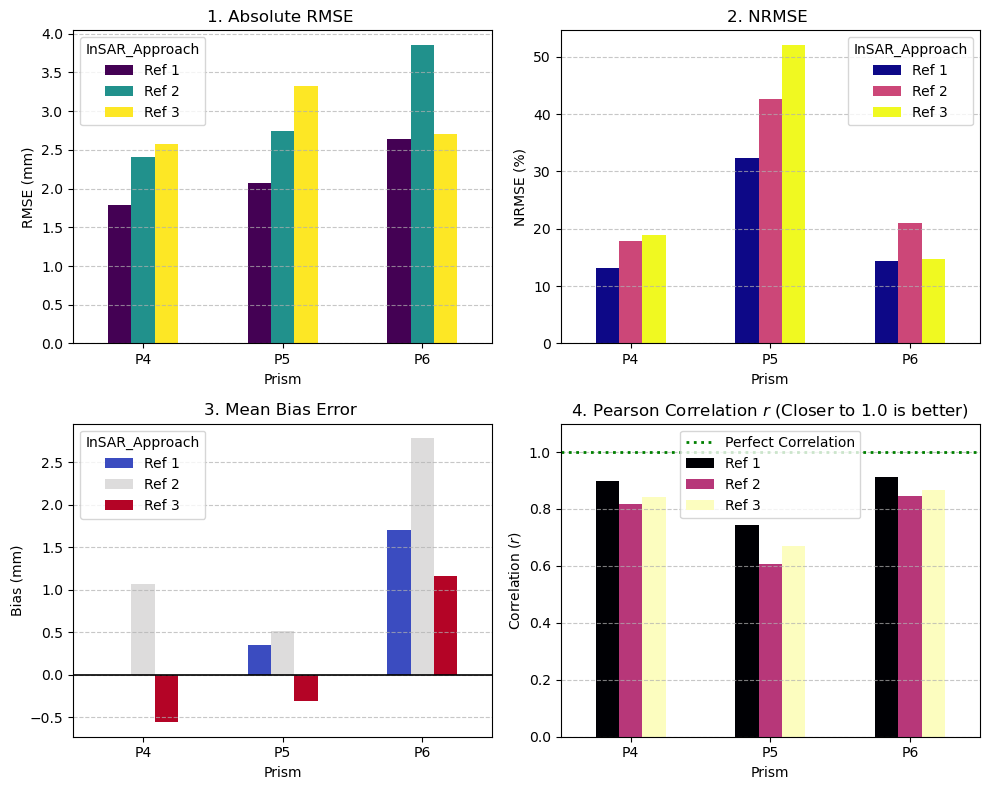

In [27]:
def plot_comprehensive_stats(rmse_df):
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    
    # Define the unique configurations for each of the 4 subplots
    plot_configs = [
        ('RMSE_mm', '1. Absolute RMSE ', 'RMSE (mm)', 'viridis'),
        ('NRMSE_%', '2. NRMSE ', 'NRMSE (%)', 'plasma'),
        ('Bias_mm', '3. Mean Bias Error ', 'Bias (mm)', 'coolwarm'),
        ('Pearson_r', '4. Pearson Correlation $r$ (Closer to 1.0 is better)', 'Correlation ($r$)', 'magma')
    ]
    
    # Loop through the flattened axes and configurations
    for ax, (val, title, ylabel, cmap) in zip(axes.flatten(), plot_configs):
        rmse_df.pivot(index='Prism', columns='InSAR_Approach', values=val).plot(kind='bar', ax=ax, colormap=cmap)
        ax.set(title=title, ylabel=ylabel)
        ax.tick_params(axis='x', rotation=0)
        ax.grid(axis='y', linestyle='--', alpha=0.7)
        if val == 'Bias_mm':
            ax.axhline(0, color='black', linewidth=1.2)
        elif val == 'Pearson_r':
            ax.set_ylim(0, 1.1)
            ax.axhline(1.0, color='green', linestyle=':', linewidth=2, label='Perfect Correlation')
            ax.legend()

    plt.tight_layout()
    plt.show()

plot_comprehensive_stats(rmse_df)